In [62]:
# author: Suhas Vittal

import importlib
from plotting import *

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

WORKLOAD_ORDER = [
    ['cam4', 'roms', 'omnetpp', 'bwaves', 'fotonik3d', 'wrf', 'lbm'],
    ['triangle', 'cf', 'pagerankdelta', 'mis', 'bc', 'bellmanford', 'pagerank', 'radii'],
    ['scale', 'copy', 'triad', 'add'],
    ['whiskey', 'charlie', 'merced', 'delta'],
    ['mix0', 'mix1', 'mix2', 'mix3', 'mix4', 'mix5']
]

ALL_WORKLOADS = []
for suite in WORKLOAD_ORDER:
    ALL_WORKLOADS.extend(suite)

ALL_WORKLOADS_PLUS_GMEAN = ALL_WORKLOADS.copy()
ALL_WORKLOADS_PLUS_GMEN

C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898121' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'

VERSION = 1

In [63]:
def plot_speedup(output_file, ax, baseline_data, policy_data: list, legend: list, colors: list, legend_ncols=1):
    ax.set_ylabel('Speedup (%)', fontsize=12)

    if type(baseline_data) is not list:
        baseline_data = [baseline_data for _ in policy_data]
    
    width = 1.0 / (len(policy_data)+1)
    offset = 0

    X = []
    _x = 0
    for suite in WORKLOAD_ORDER:
        X.extend(list(range(_x, _x+len(suite))))
        _x += len(suite)+1
    X = np.array(X)
    
    for (i, pd) in enumerate(policy_data):
        bd = baseline_data[i]
        label = legend[i]
        Y = []
        for suite in WORKLOAD_ORDER:
            for w in suite:
                baseline_ipc = bd[w]['IPC']
                policy_ipc = pd[w]['IPC']
                Y.append(policy_ipc/baseline_ipc)
            # plot bar:
        Y = np.array(Y)
        Y = (Y-1)*100
        ax.bar(X+offset, Y, width, color=colors[i], label=legend[i], edgecolor='k', zorder=3)
        offset += width

    # set x labels to workloads
    workload_x_ticks = X + (len(legend)-1)/2 * width
    ax.set_xticks(workload_x_ticks, ALL_WORKLOADS, rotation=30, ha='right', fontsize=10)
    ax.grid(visible=True, axis='y', zorder=0)
    ax.legend(fontsize=10, ncols=legend_ncols, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

In [64]:
BASELINE = read_csv_data('../data/baseline.csv')
BARD = read_csv_data('../data/bard.csv')
BARD_E = read_csv_data('../data/bard_e.csv')
BARD_C = read_csv_data('../data/bard_c.csv')
EAGER = read_csv_data('../data/eager.csv')
VWQ = read_csv_data('../data/vwq.csv')

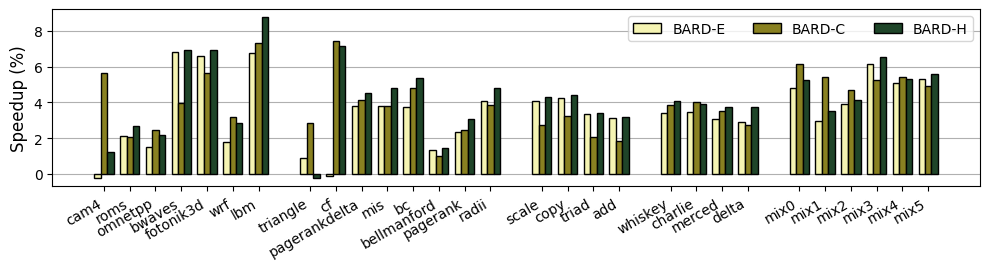

In [65]:
fig, ax = plt.subplots()
fig.set_size_inches(10.0, 2.8)

plot_speedup(f'bard_plots/v{VERSION}_bard_speedup_all_versions.pdf', ax,
            BASELINE,
            [BARD_E, BARD_C, BARD], ['BARD-E', 'BARD-C', 'BARD-H'],
            colors=[C1,C2,C3],
            legend_ncols=3)

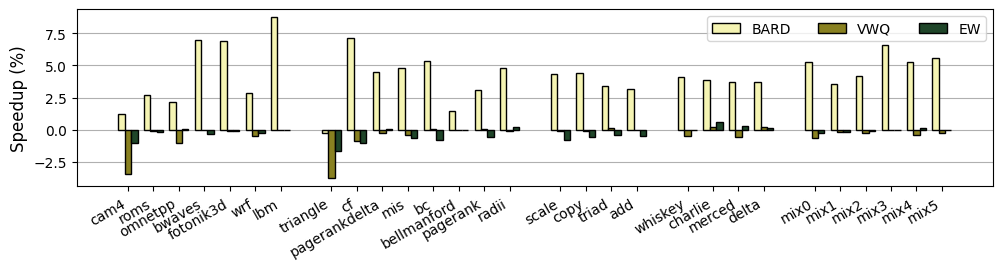

In [66]:
fig, ax = plt.subplots()
fig.set_size_inches(10.0, 2.8)

plot_speedup(f'bard_plots/v{VERSION}_bard_speedup_with_vwq_and_eager.pdf', ax,
             BASELINE,
             [BARD, EAGER, VWQ], ['BARD', 'VWQ', 'EW'],
             colors=[C1,C2,C3],
            legend_ncols=3)

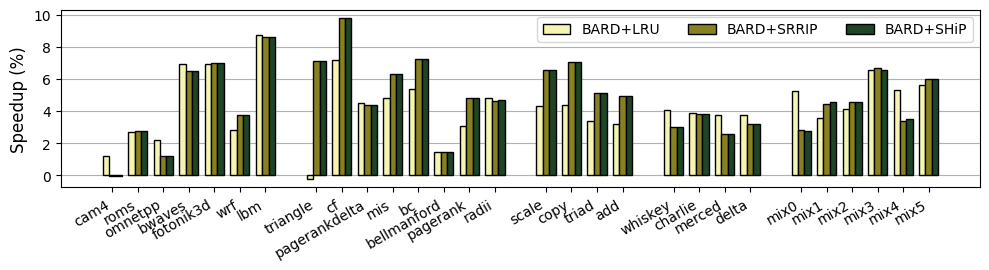

In [67]:
BASELINE_SRRIP = read_csv_data('../data/baseline_srrip.csv')
BASELINE_SHIP = read_csv_data('../data/baseline_ship.csv')
BARD_SRRIP = read_csv_data('../data/bard_srrip.csv')
BARD_SHIP = read_csv_data('../data/bard_ship.csv')

fig, ax = plt.subplots()
fig.set_size_inches(10.0, 2.8)

plot_speedup(f'bard_plots/v{VERSION}_bard_speedup_different_repl.pdf', ax,
             [BASELINE, BASELINE_SRRIP, BASELINE_SHIP],
             [BARD, BARD_SRRIP, BARD_SHIP], ['BARD+LRU', 'BARD+SRRIP', 'BARD+SHiP'],
            colors=[C1,C2,C3],
            legend_ncols=3)
             